# **Project Name**    -  Amazon Prime Movies & TV Shows Analysis



##### **Project Type**    - EDA
##### **Contribution**    - Individual

# **Project Summary -**

This project focuses on performing Exploratory Data Analysis (EDA) on the Amazon Prime Movies and TV Shows dataset. The main objective is to analyze and understand the structure of the dataset and prepare it for extracting meaningful insights that can support business decision-making.

The dataset consists of two primary components: titles and credits. The titles dataset includes information such as genre, release year, runtime, IMDb score, and production country, while the credits dataset contains details about actors and directors associated with each title. These datasets are combined to create a comprehensive view of the content available on the platform.

Data preprocessing is an essential part of this project, which includes handling missing values, removing duplicates, and transforming data into a structured format suitable for analysis. Feature engineering techniques are also applied to enhance the dataset and make it more useful for exploration.

The project follows a structured approach using univariate, bivariate, and multivariate analysis techniques. Various visualization tools are used to represent the data effectively and to explore relationships between different variables.

Overall, this project aims to build a strong understanding of the dataset and demonstrate how data analysis techniques can be applied to real-world business problems in the streaming industry.

# **GitHub Link -**

Provide your GitHub Link here.

# **Problem Statement**


With the rapid growth of streaming platforms, a huge amount of content is available to users. However, it becomes difficult to understand which type of content attracts more viewers and performs better. Amazon Prime has a large collection of movies and TV shows, but there is a need to analyze this data to identify patterns and trends.

This project focuses on exploring the dataset to better understand content distribution, audience preferences, and the factors that may influence content performance.

#### **Business Objective**

The main objective of this project is to analyze the content available on Amazon Prime and understand what drives its performance.

This includes:

* Identifying popular genres and content types
* Understanding what affects ratings and popularity
* Studying trends in content over the years

The goal is to use these insights to help improve content strategy, user engagement, and overall platform growth.

## ***1.Data***

### Import Libraries

In [2]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

### Dataset Loading

In [3]:
# Load Dataset
titles = pd.read_csv('cleaned_titles.csv')
credits = pd.read_csv('credits.csv')

### Dataset First View

In [4]:
# Dataset First Look

print("Titles Dataset:")
display(titles.head())

print("\nCredits Dataset:")
display(credits.head())

Titles Dataset:


,id,title,type,description,release_year,age_certification,runtime,genres,production_countries,seasons,imdb_id,imdb_score,imdb_votes,tmdb_popularity,tmdb_score
0,ts20945,The Three Stooges,SHOW,The Three Stooges were an American vaudeville ...,1934,TV-PG,19,"comedy, family, animation, action, fantasy, ho...",US,26.0,tt0850645,8.6,1092.0,15.424,7.6
1,tm19248,The General,MOVIE,"During America’s Civil War, Union spies steal ...",1926,NaN,78,"action, drama, war, western, comedy, european",US,NaN,tt0017925,8.2,89766.0,8.647,8.0
2,tm82253,The Best Years of Our Lives,MOVIE,It's the hope that sustains the spirit of ever...,1946,NaN,171,"romance, war, drama",US,NaN,tt0036868,8.1,63026.0,8.435,7.8
3,tm83884,His Girl Friday,MOVIE,"Hildy, the journalist former wife of newspaper...",1940,NaN,92,"comedy, drama, romance",US,NaN,tt0032599,7.8,57835.0,11.270,7.4
4,tm56584,In a Lonely Place,MOVIE,An aspiring actress begins to suspect that her...,1950,NaN,94,"thriller, drama, romance",US,NaN,tt0042593,7.9,30924.0,8.273,7.6



Credits Dataset:


,person_id,id,name,character,role
0,59401,ts20945,Joe Besser,Joe,ACTOR
1,31460,ts20945,Moe Howard,Moe,ACTOR
2,31461,ts20945,Larry Fine,Larry,ACTOR
3,21174,tm19248,Buster Keaton,Johnny Gray,ACTOR
4,28713,tm19248,Marion Mack,Annabelle Lee,ACTOR


### Dataset Rows & Columns count

In [5]:
# Dataset Rows & Columns count

print("Titles Shape:", titles.shape)
print("Credits Shape:", credits.shape)

Titles Shape: (9871, 15)
Credits Shape: (124235, 5)


### Dataset Information

In [6]:
# Dataset Info
print("Titles Info:\n")
print(titles.info())

print("\nCredits Info:\n")
print(credits.info())

Titles Info:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9871 entries, 0 to 9870
Data columns (total 15 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id                    9871 non-null   object 
 1   title                 9871 non-null   object 
 2   type                  9871 non-null   object 
 3   description           9752 non-null   object 
 4   release_year          9871 non-null   int64  
 5   age_certification     3384 non-null   object 
 6   runtime               9871 non-null   int64  
 7   genres                9662 non-null   object 
 8   production_countries  9050 non-null   object 
 9   seasons               1357 non-null   float64
 10  imdb_id               9204 non-null   object 
 11  imdb_score            8850 non-null   float64
 12  imdb_votes            8840 non-null   float64
 13  tmdb_popularity       9324 non-null   float64
 14  tmdb_score            7789 non-null   float64
dtypes: floa

#### Duplicate Values

In [7]:
# Dataset Duplicate Value Count

print("Titles Duplicate Values:", titles.duplicated().sum())
print("Credits Duplicate Values:", credits.duplicated().sum())

Titles Duplicate Values: 3
Credits Duplicate Values: 56


#### Missing Values/Null Values

In [8]:
# Missing Values/Null Values Count

print("Missing Values in Titles:\n")
print(titles.isnull().sum())

print("\nMissing Values in Credits:\n")
print(credits.isnull().sum())

Missing Values in Titles:

id                         0
title                      0
type                       0
description              119
release_year               0
age_certification       6487
runtime                    0
genres                   209
production_countries     821
seasons                 8514
imdb_id                  667
imdb_score              1021
imdb_votes              1031
tmdb_popularity          547
tmdb_score              2082
dtype: int64

Missing Values in Credits:

person_id        0
id               0
name             0
character    16287
role             0
dtype: int64


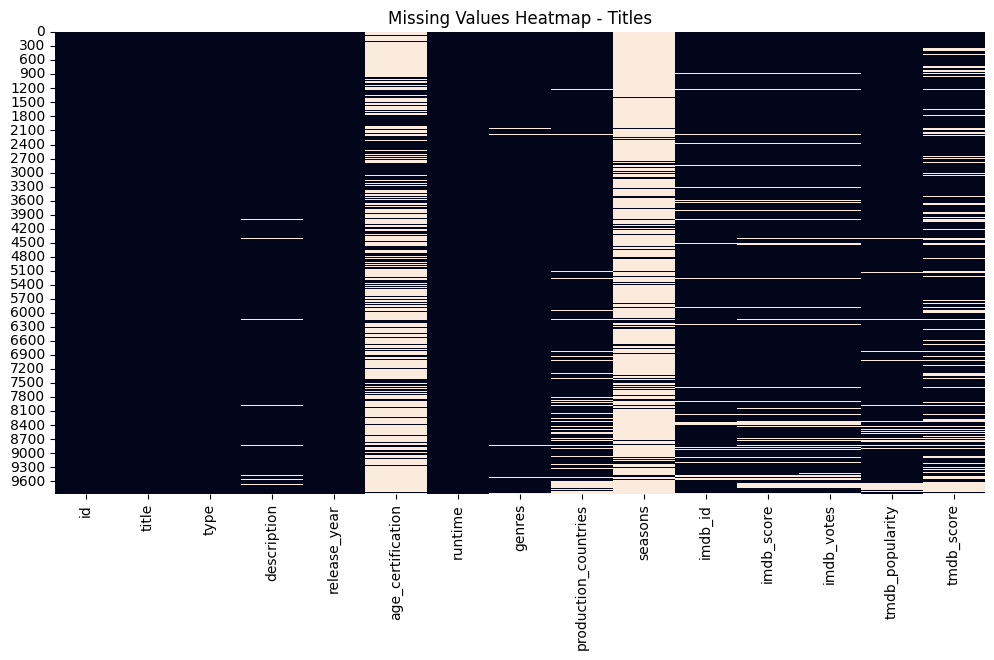

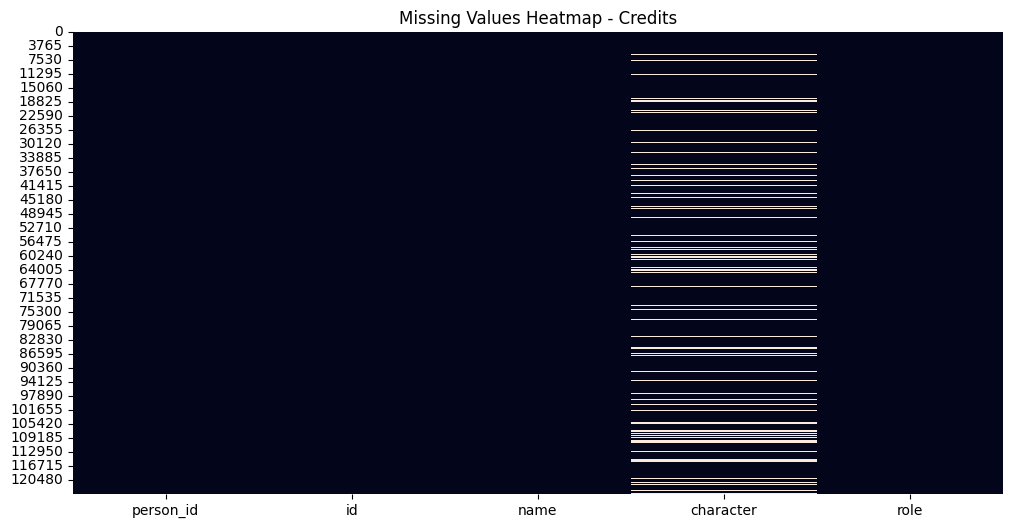

In [9]:
# Visualizing the missing values

plt.figure(figsize=(12,6))
sns.heatmap(titles.isnull(), cbar=False)
plt.title("Missing Values Heatmap - Titles")
plt.show()

plt.figure(figsize=(12,6))
sns.heatmap(credits.isnull(), cbar=False)
plt.title("Missing Values Heatmap - Credits")
plt.show()

In [10]:
# Missing values count
missing_titles = titles.isnull().sum().sort_values(ascending=False)
missing_credits = credits.isnull().sum().sort_values(ascending=False)

print("Titles Missing Values:\n", missing_titles)
print("\nCredits Missing Values:\n", missing_credits)

Titles Missing Values:
 seasons                 8514
age_certification       6487
tmdb_score              2082
imdb_votes              1031
imdb_score              1021
production_countries     821
imdb_id                  667
tmdb_popularity          547
genres                   209
description              119
runtime                    0
id                         0
release_year               0
title                      0
type                       0
dtype: int64

Credits Missing Values:
 character    16287
person_id        0
id               0
name             0
role             0
dtype: int64


Before starting the analysis, the dataset appears to contain information about movies and TV shows available on Amazon Prime. It includes features such as title, genre, release year, runtime, IMDb score, and production country. Another dataset contains details about actors and directors.

At first glance, the dataset seems to have a mix of numerical and categorical data. There may be missing values and duplicate entries that need to be handled during data cleaning. The data will require preprocessing before performing any detailed analysis.

Overall, the dataset looks suitable for exploring content patterns and understanding different aspects of streaming data.

## ***2. Understanding Variables***

In [11]:
# Dataset Columns
print("Titles Columns:", titles.columns)
print("Credits Columns:", credits.columns)

Titles Columns: Index(['id', 'title', 'type', 'description', 'release_year',
       'age_certification', 'runtime', 'genres', 'production_countries',
       'seasons', 'imdb_id', 'imdb_score', 'imdb_votes', 'tmdb_popularity',
       'tmdb_score'],
      dtype='object')
Credits Columns: Index(['person_id', 'id', 'name', 'character', 'role'], dtype='object')


#### Titles Dataset Variables:

* id: Unique identifier for each title

* title: Name of the movie or TV show

* type: Indicates whether the content is a Movie or TV Show

* description: Short summary of the content (used for NLP & recommendation)

* release_year: Year in which the content was released

* age_certification: Audience suitability (e.g., PG, R)

* runtime: Duration of the content in minutes

* genres: Categories like Drama, Comedy, Action

* production_countries: Country of origin

* seasons: Number of seasons (for TV shows)

* imdb_id: IMDb identifier

* imdb_score: Rating given by users on IMDb

* imdb_votes: Number of votes on IMDb

* tmdb_popularity: Popularity score from TMDB

* tmdb_score: Rating from TMDB

#### Credits Dataset Variables:
* id: Unique identifier for each title
* name: Name of the person involved in the content (actor or director)
* character: Name of the character played by the actor (if applicable)
* role: Role of the person, such as ACTOR or DIRECTOR

### Check Unique Values for each variable.

In [12]:
# Check Unique Values for each variable.

object_columns = credits[['name', 'character', 'role']].columns

unique_values = {}
for col in object_columns:
    unique_values[col] = credits[col].unique()

# Display results
for col, values in unique_values.items():
    print(f"\nColumn: {col}")
    print(f"Number of unique values: {len(values)}")
    print(f"Sample values: {values}")


    


Column: name
Number of unique values: 79758
Sample values: ['Joe Besser' 'Moe Howard' 'Larry Fine' ... 'Vijay Thakur' 'Vanya Wellens'
 'Vishwa Bhanu']

Column: character
Number of unique values: 71098
Sample values: ['Joe' 'Moe' 'Larry' ... 'Sanjay Thakur' 'Budhiya' 'Gissu']

Column: role
Number of unique values: 2
Sample values: ['ACTOR' 'DIRECTOR']


In [13]:
# Check Unique Values for each variable.
object_columns = titles[['type', 'age_certification', 'genres', 'production_countries']].columns

unique_values = {}
for col in object_columns:
    unique_values[col] = titles[col].unique()

# Display results
for col, values in unique_values.items():
    print(f"\nColumn: {col}")
    print(f"Number of unique values: {len(values)}")
    print(f"Sample values: {values}")  # show first 10 unique values


Column: type
Number of unique values: 2
Sample values: ['SHOW' 'MOVIE']

Column: age_certification
Number of unique values: 12
Sample values: ['TV-PG' nan 'PG' 'G' 'PG-13' 'R' 'TV-G' 'TV-Y' 'TV-14' 'NC-17' 'TV-Y7'
 'TV-MA']

Column: genres
Number of unique values: 2028
Sample values: ['comedy, family, animation, action, fantasy, horror'
 'action, drama, war, western, comedy, european' 'romance, war, drama' ...
 'drama, family, thriller' 'thriller, western, comedy'
 'comedy, action, family']

Column: production_countries
Number of unique values: 497
Sample values: ['US' 'GB' 'MX, US' 'GB, CA' 'DE, US' 'SU' nan 'IN' 'CA, US' 'MX' 'XX'
 'US, IT' 'JP' 'IT, FR' 'HK' 'FR, DE, IT' 'ES, IT' 'GB, US' 'IL, US'
 'US, FR, IT' 'IT' 'IT, GB, US' 'GB, US, IT, MX, ES' 'AU, US' 'CH, GB'
 'CA, FR' 'US, IE' 'GB, IT' 'IT, US' 'FR' 'GR, US' 'DE' 'HK, US, CN'
 'US, ES' 'PH, US' 'NL, US' 'FR, US' 'IT, YU' 'FR, DE, CH, CI' 'PR, US'
 'US, PH' 'YU, US' 'IT, MX' 'IT, ES, DE, LI' 'US, CA' 'US, GB' 'US, DE'
 'US,

## 3. ***Data cleaning***

In [14]:
# Write your code to make your dataset analysis ready.
# Replace empty lists with NaN
titles['genres'] = titles['genres'].replace("[]", np.nan)
titles['production_countries'] = titles['production_countries'].replace("[]", np.nan)

In [15]:
# Remove duplicates
titles = titles.drop_duplicates()
credits = credits.drop_duplicates()

In [16]:
## removing rows with missing values in 'genres' and 'production_countries'
titles = titles.dropna(subset=['genres', 'production_countries']) 

In [17]:
credits = credits.fillna({"character": "Unknown"})

In [18]:
# Separate actors and directors
actors = credits[credits['role'] == 'ACTOR']
directors = credits[credits['role'] == 'DIRECTOR']

In [19]:
# Group actors per title
actors_grouped = actors.groupby('id')['name'].apply(lambda x: ', '.join(x)).reset_index()
actors_grouped.rename(columns={'name': 'actors'}, inplace=True)

# Group directors per title
directors_grouped = directors.groupby('id')['name'].apply(lambda x: ', '.join(x)).reset_index()
directors_grouped.rename(columns={'name': 'directors'}, inplace=True)

In [20]:
# Merge actors
df = titles.merge(actors_grouped, on='id', how='left')

# Merge directors
df = df.merge(directors_grouped, on='id', how='left')

To make the dataset ready for analysis, several preprocessing steps were performed. First, empty lists in the genres and production_countries columns were replaced with null values to handle missing data properly. Duplicate records were removed from both datasets to ensure data quality.

Rows with missing values in important columns like genres and production countries were removed, as they are essential for analysis. Missing values in the character column were filled with "Unknown" to maintain consistency.

The credits dataset was then separated into actors and directors based on their roles. These were grouped by title to combine multiple actors and directors into single columns. Finally, the titles dataset was merged with the grouped actors and directors data to create a complete dataset for analysis.

#### Insights:
After preprocessing, the dataset became more structured and reliable. It allowed better understanding of content along with associated actors and directors, making it easier to perform detailed analysis and visualization.

## ***4. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables***

#### Chart 1: Content Type Distribution

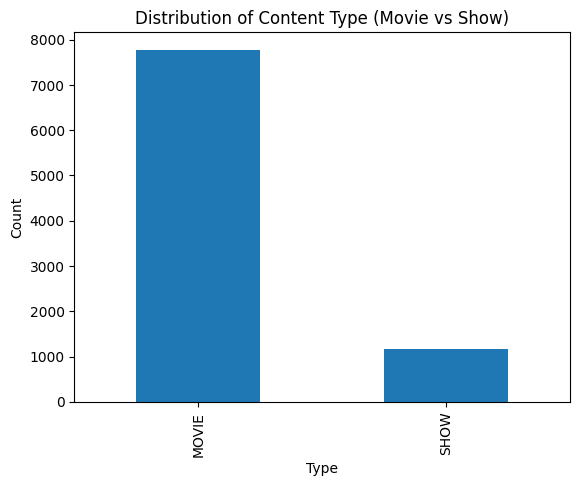

In [21]:
# Chart - 1 

df['type'].value_counts().plot(kind='bar')
plt.title("Distribution of Content Type (Movie vs Show)")
plt.xlabel("Type")
plt.ylabel("Count")
plt.show()

##### 1. Purpose

A bar chart is ideal for comparing categorical variables like content type, making it easy to see which type dominates the platform.

##### 2. insights

Movies significantly outnumber TV shows on Amazon Prime, indicating a strong focus on movie content.

##### 3. Business impact
* Positive: Helps platform prioritize movie production and acquisition strategies.
* Negative: Fewer shows may reduce user engagement because series keep users watching for longer.

#### Chart 2: Top Genres

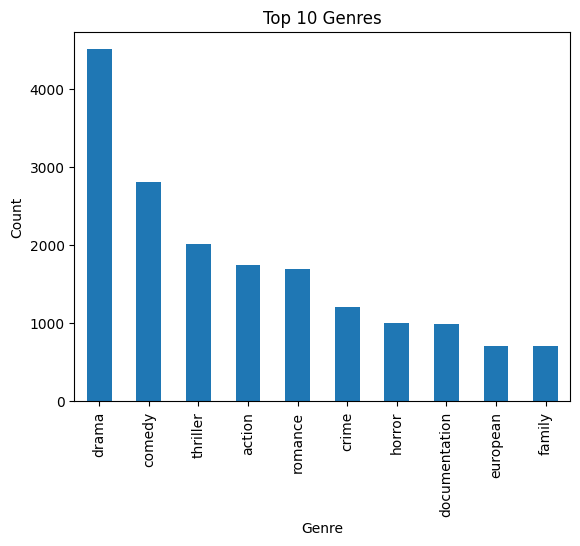

In [22]:
# Chart - 2 visualization code

df['genres'] = df['genres'].str.replace('[\[\]\']', '', regex=True)
genre_counts = df['genres'].str.split(', ').explode().value_counts().head(10)

genre_counts.plot(kind='bar')
plt.title("Top 10 Genres")
plt.xlabel("Genre")
plt.ylabel("Count")
plt.show()

##### 1. Purpose

A bar chart is suitable for comparing frequencies of different genres, helping identify the most common content categories.

##### 2. insights

Drama is the most dominant genre, followed by comedy and thriller. This shows a strong preference for emotional and entertainment-driven content.

##### 3. Business impact

* Positive: Helps in focusing production on popular genres like drama and comedy.
* Negative: Too much focus on similar genres may reduce variety and limit audience reach.

#### Chart - 3 Content Release Trend Over Years

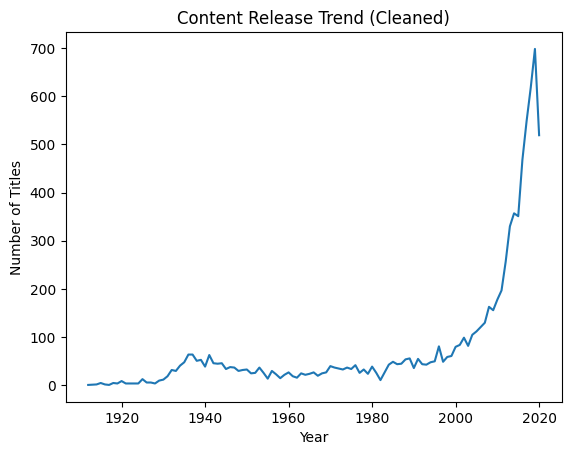

In [23]:
# Chart - 3 visualization code

df_year = df[df['release_year'] <= 2020]

df_year['release_year'].value_counts().sort_index().plot()
plt.title("Content Release Trend (Cleaned)")
plt.xlabel("Year")
plt.ylabel("Number of Titles")
plt.show()

##### 1. Purpose

A line chart is ideal for analyzing trends over time, showing how content production has evolved across years.

##### 2. insights

There is a sharp increase in content releases after 2000, with rapid growth in recent years, especially after 2015.

##### 3. Business impact

* Positive: Indicates platform expansion and increasing content investment.
* Negative: Rapid growth may lead to inconsistent content quality if not managed properly.

#### Chart 4: IMDb Score Distribution

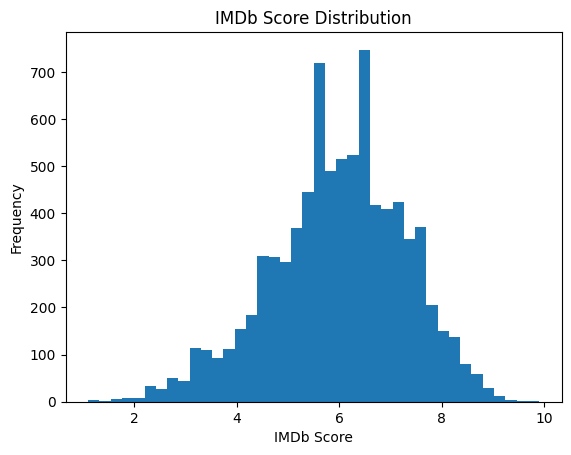

In [24]:
# Chart - 4 visualization code

df['imdb_score'].plot(kind='hist', bins=40)
plt.title("IMDb Score Distribution")
plt.xlabel("IMDb Score")
plt.ylabel("Frequency")
plt.show()

##### 1. Purpose

A histogram is used to understand the distribution of a numerical variable like IMDb scores.

##### 2. insights

Most content falls between IMDb scores of 5 to 7, indicating a large portion of average-rated content.

##### 3. Business impact

* Positive: Shows a consistent level of acceptable content quality.
* Negative: Fewer high-rated titles (>8) may impact platform reputation for premium content.

#### Chart - 5 Top 10 Countries Producing Content

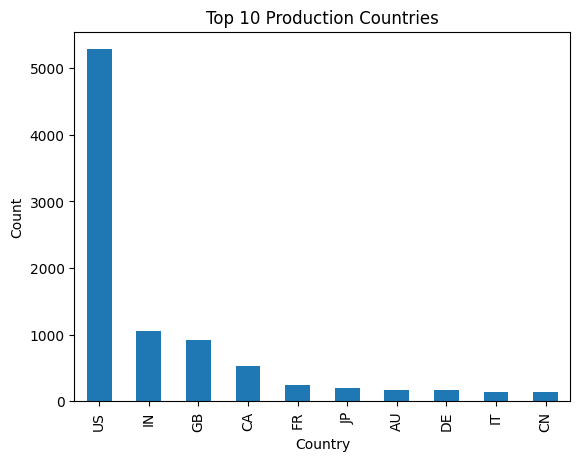

In [25]:
# Chart - 5 visualization code

df['production_countries'] = df['production_countries'].str.replace('[\[\]\']', '', regex=True)
country_counts = df['production_countries'].str.split(', ').explode().value_counts().head(10)

country_counts.plot(kind='bar')
plt.title("Top 10 Production Countries")
plt.xlabel("Country")
plt.ylabel("Count")
plt.show()

##### 1. Purpose

A bar chart helps compare content production across different countries and identify dominant regions.

##### 2. insights

The United States produces the highest amount of content, followed by countries like India, the UK, and Canada.

##### 3. Business impact

* Positive: Helps identify key markets contributing most content.
* Negative: Heavy reliance on a few countries may limit global diversity and audience expansion.

#### Chart - 6 Movie Duration Distribution

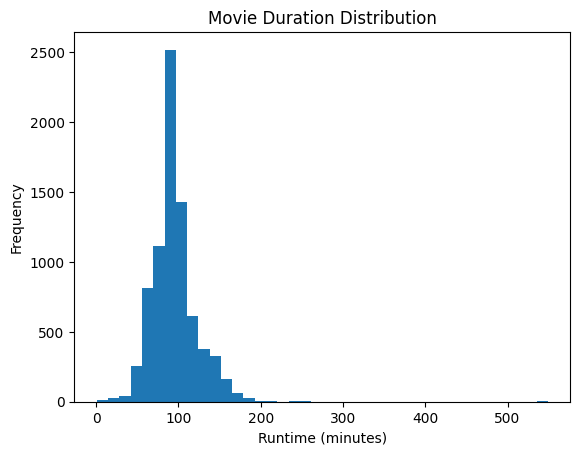

In [26]:
# Chart - 6 visualization code

df[df['type'] == 'MOVIE']['runtime'].plot(kind='hist', bins=40)
plt.title("Movie Duration Distribution")
plt.xlabel("Runtime (minutes)")
plt.ylabel("Frequency")
plt.show()

##### 1. Purpose

A histogram is effective for understanding the distribution of movie durations and identifying common runtime ranges.

##### 2. insights

Most movies have a runtime between 80 to 120 minutes, indicating a standard preferred duration.

##### 3. Business impact

* Positive: Helps in optimizing movie length for better audience engagement.
* Negative: Very long or very short movies are less common, suggesting they may not perform as well.

#### Chart - 7 IMDb Score vs Runtime

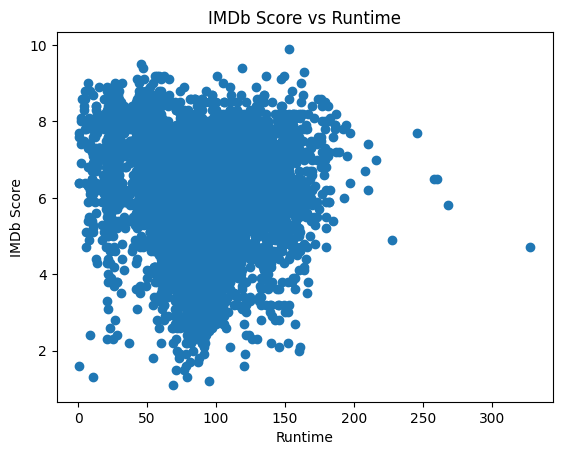

In [27]:
# Chart - 7 visualization code

plt.scatter(df['runtime'], df['imdb_score'])
plt.title("IMDb Score vs Runtime")
plt.xlabel("Runtime")
plt.ylabel("IMDb Score")
plt.show()

##### 1. Purpose

A scatter plot is ideal for analyzing the relationship between two numerical variables like runtime and IMDb score

##### 2. insights

Runtime shows no strong relationship with IMDb score, suggesting duration does not determine content quality.

##### 3. Business impact

* Positive: Helps in optimizing production costs since longer duration doesn’t guarantee better performance.
* Negative: Investing heavily in long-duration content may not improve audience satisfaction.

#### Chart - 8 Age Certification Distribution

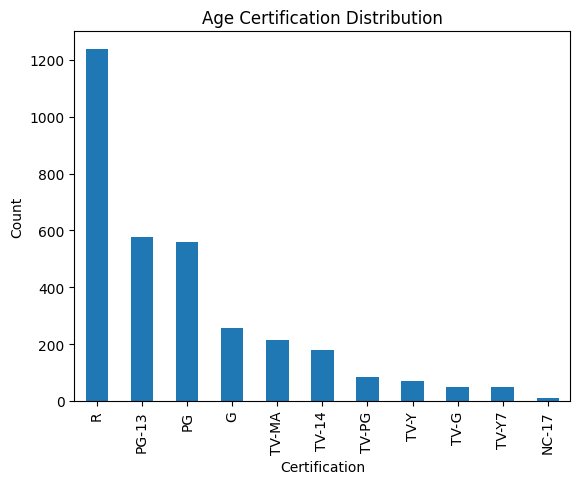

In [28]:
# Chart - 8 visualization code

df['age_certification'].value_counts().plot(kind='bar')
plt.title("Age Certification Distribution")
plt.xlabel("Certification")
plt.ylabel("Count")
plt.show()

##### 1. Purpose

A bar chart is useful for comparing the distribution of categorical variables like age certifications.

##### 2. insights

The R rating is the most common, followed by PG-13 and PG. This indicates that most content is targeted toward mature audiences, largely driven by movies.

##### 3. Business impact

* Positive: Strong focus on adult audience increases engagement for mature content.
* Negative: Less content for children and family audiences may limit subscriber diversity.

#### Chart - 9 Top 10 Directors

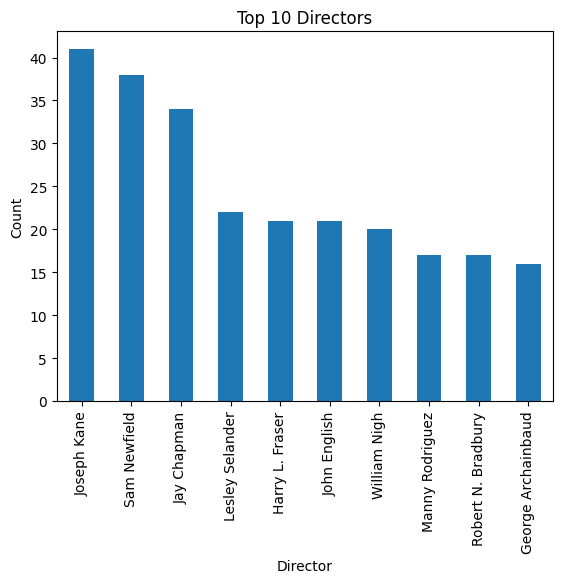

In [29]:
# Chart - 9 visualization code

top_directors = df['directors'].str.split(', ').explode().value_counts().head(10)

top_directors.plot(kind='bar')
plt.title("Top 10 Directors")
plt.xlabel("Director")
plt.ylabel("Count")
plt.show()

##### 1. Purpose

A bar chart is useful for identifying the most frequent directors and comparing their contribution to the platform.

##### 2. insights

A few directors like Joseph Kane and Sam Newfield appear most frequently, indicating repeated collaborations or bulk content contributions.

##### 3. Business impact

* Positive: Helps identify experienced and frequently contributing directors for future projects.
* Negative: Too many projects with the same directors may reduce variety and new ideas.

#### Chart 10: Top 10 Actors

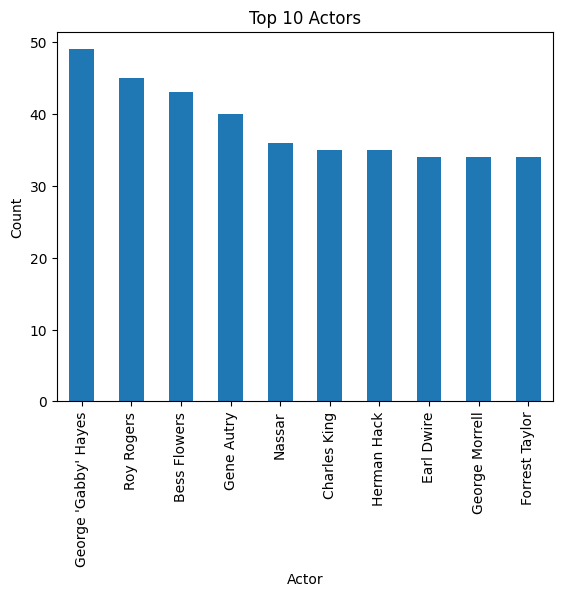

In [30]:
# Chart - 10 visualization code

top_actors = df['actors'].str.split(', ').explode().value_counts().head(10)

top_actors.plot(kind='bar')
plt.title("Top 10 Actors")
plt.xlabel("Actor")
plt.ylabel("Count")
plt.show()

##### 1. Purpose

A bar chart helps compare the frequency of actors appearing in the dataset.

##### 2. insights

Actors like George ‘Gabby’ Hayes and Roy Rogers appear most frequently, indicating repeated appearances in multiple titles.

##### 3. Business impact

* Positive: Helps identify popular or frequently cast actors.
* Negative: Repeating the same actors too often may reduce content variety.

#### Chart 11: IMDb Score vs Type (Boxplot)

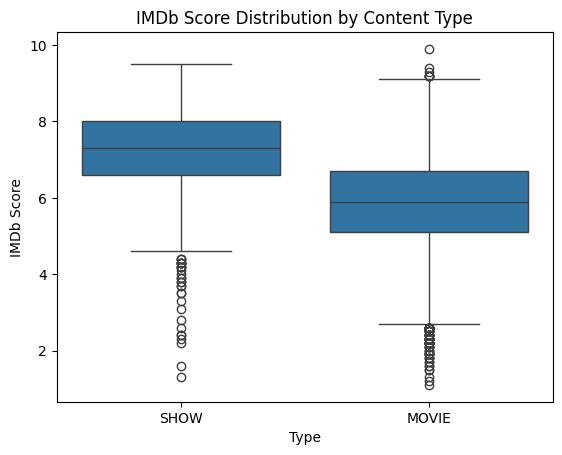

In [31]:
# Chart - 11 visualization code

sns.boxplot(x='type', y='imdb_score', data=df)
plt.title("IMDb Score Distribution by Content Type")
plt.xlabel("Type")
plt.ylabel("IMDb Score")
plt.show()

##### 1. Purpose

A box plot is useful for comparing the distribution of IMDb scores between movies and shows.

##### 2. insights

TV shows generally have slightly higher median IMDb scores, while movies show more variation and lower scores.

##### 3. Business impact

* Positive: Investing in shows can improve overall content quality perception.
* Negative: Movies with lower ratings may reduce user satisfaction.

#### Chart 12: Runtime vs Type

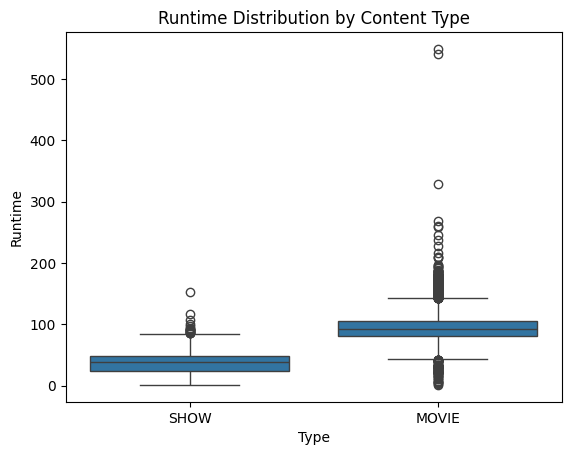

In [32]:
# Chart - 12 visualization code

sns.boxplot(x='type', y='runtime', data=df)
plt.title("Runtime Distribution by Content Type")
plt.xlabel("Type")
plt.ylabel("Runtime")
plt.show()

##### 1. Purpose

A box plot is used to compare runtime distribution between movies and TV shows.

##### 2. insights

Movies generally have a higher and wider runtime range, while shows have shorter and more consistent durations.

##### 3. Business impact

* Positive: Helps in planning content duration based on audience preference.
* Negative: Longer movies may not always retain viewer attention.

#### Chart 13: IMDb Score vs Release Year

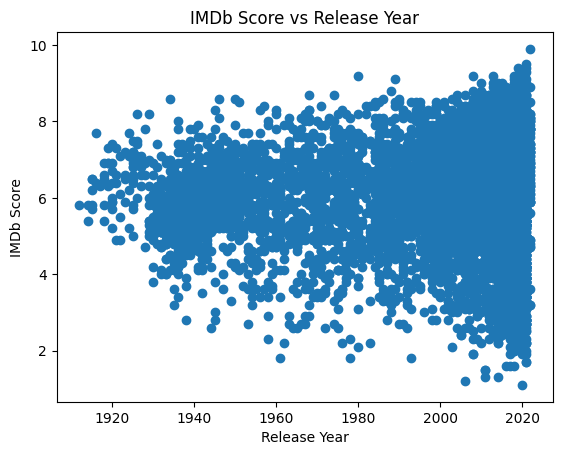

In [33]:
# Chart - 13 visualization code

plt.scatter(df['release_year'], df['imdb_score'])
plt.title("IMDb Score vs Release Year")
plt.xlabel("Release Year")
plt.ylabel("IMDb Score")
plt.show()

##### 1. Purpose

A scatter plot helps analyze the relationship between release year and IMDb score over time.

##### 2. insights

There is no strong trend between release year and IMDb score, but recent content shows a wider variation in ratings.

##### 3. Business impact

* Positive: Indicates continuous content production across years.
* Negative: Inconsistent ratings in recent content may affect platform credibility.

#### Chart 14: Genre vs IMDb Score (Top Genres)

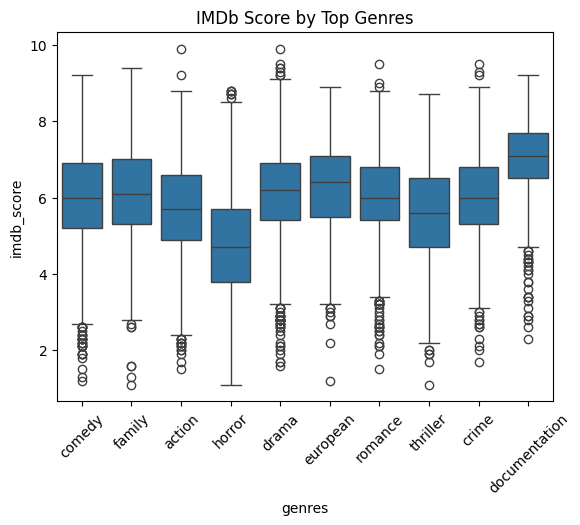

In [34]:
# Chart - 14 visualization code (FIXED)

# Explode genres properly
genre_exploded = df.copy()
genre_exploded['genres'] = genre_exploded['genres'].str.split(', ')
genre_exploded = genre_exploded.explode('genres').reset_index(drop=True)

# Remove missing values
genre_exploded = genre_exploded.dropna(subset=['genres', 'imdb_score'])

# Get top genres
top_genres = genre_exploded['genres'].value_counts().head(10).index
filtered = genre_exploded[genre_exploded['genres'].isin(top_genres)]

# Plot
sns.boxplot(x='genres', y='imdb_score', data=filtered)
plt.xticks(rotation=45)
plt.title("IMDb Score by Top Genres")
plt.show()
plt.show()

##### 1. Purpose

A box plot helps compare IMDb score distribution across different genres.

##### 2. insights

Some genres like Drama and Documentary tend to have higher IMDb scores, while others show more variation.

##### 3. Business impact

* Positive: Helps focus on high-performing genres for better audience satisfaction.
* Negative: Ignoring low-performing genres completely may reduce content diversity.

#### Chart 15: Country vs IMDb Score

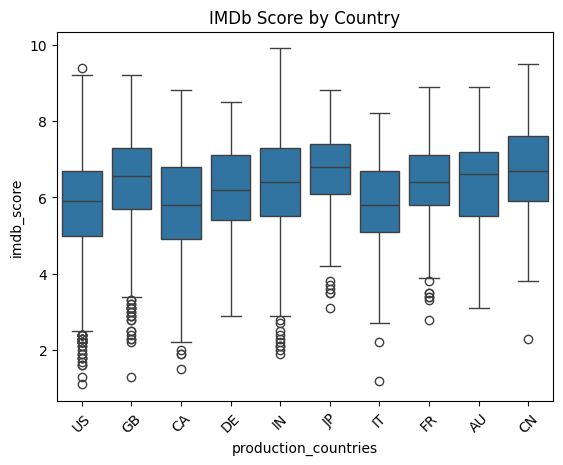

In [35]:
# Chart - 15 visualization code (FIXED)

# Proper explode with index reset
country_exploded = df.copy()
country_exploded['production_countries'] = country_exploded['production_countries'].str.split(', ')
country_exploded = country_exploded.explode('production_countries').reset_index(drop=True)

# Remove missing values
country_exploded = country_exploded.dropna(subset=['production_countries', 'imdb_score'])

# Top countries
top_countries = country_exploded['production_countries'].value_counts().head(10).index
filtered = country_exploded[country_exploded['production_countries'].isin(top_countries)]

# Plot
sns.boxplot(x='production_countries', y='imdb_score', data=filtered)
plt.xticks(rotation=45)
plt.title("IMDb Score by Country")
plt.show()

##### 1. Purpose

A box plot is useful for comparing IMDb score distributions across different countries.

##### 2. insights

Some countries like the US and UK show a wide range of IMDb scores, while others have more consistent ratings.

##### 3. Business impact

* Positive: Helps identify countries producing high-quality content.
* Negative: Focusing only on a few countries may limit global content diversity.

#### Chart 14: Correlation Heatmap

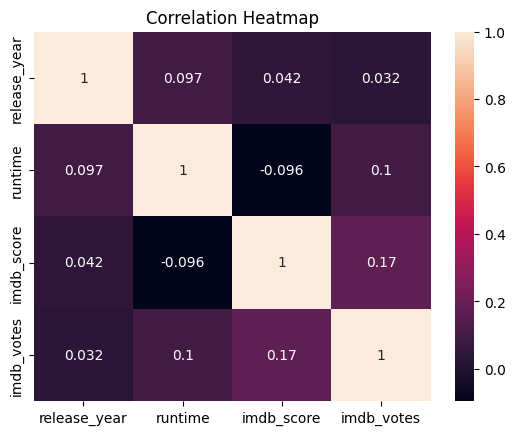

In [36]:
# Chart - 16 visualization code

numeric_cols = ['release_year', 'runtime', 'imdb_score', 'imdb_votes']

corr = df[numeric_cols].corr()

sns.heatmap(corr, annot=True)
plt.title("Correlation Heatmap")
plt.show()

##### 1. Purpose

A heatmap is used to visualize correlations between numerical variables in a clear and compact way.

##### 2. insights

The heatmap shows weak correlations, indicating that multiple factors influence content performance.

##### 3. Business impact

* Positive: Helps identify key factors (like votes) influencing ratings.
* Negative: Weak correlations suggest that no single factor strongly determines content success.

#### Chart 17: IMDb Votes vs Score

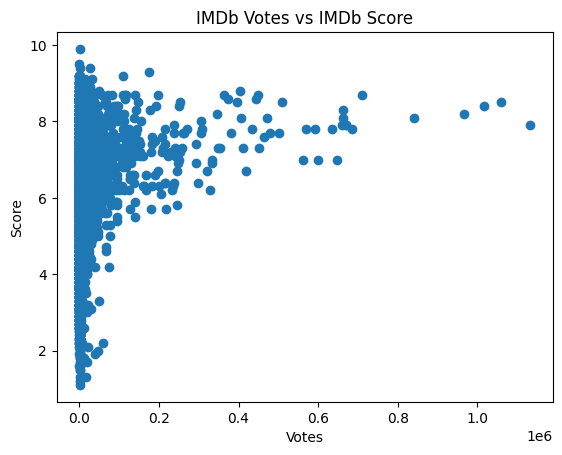

In [37]:
# Chart - 17 visualization code

plt.scatter(df['imdb_votes'], df['imdb_score'])
plt.title("IMDb Votes vs IMDb Score")
plt.xlabel("Votes")
plt.ylabel("Score")
plt.show()

##### 1. Purpose

A scatter plot is ideal for analyzing the relationship between two numerical variables like IMDb votes and IMDb score.

##### 2. insights

Most content has low votes with scattered ratings, while highly voted content tends to have stable ratings.

##### 3. Business impact

* Positive: Highly popular content tends to maintain decent ratings, indicating reliable audience approval.
* Negative: Many low-vote titles have inconsistent ratings, suggesting visibility and engagement issues.

#### Chart 18: Age Certification vs IMDb Score

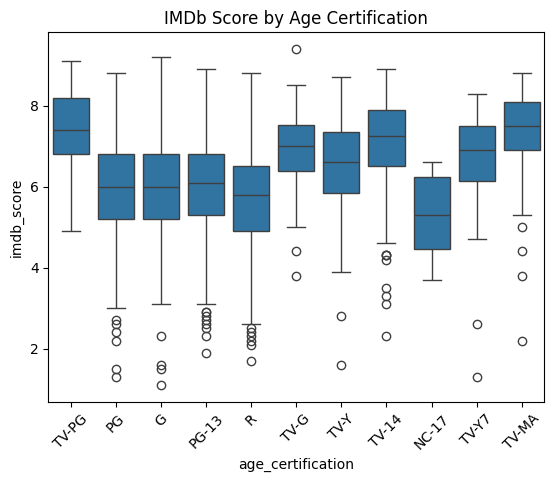

In [38]:
# Chart - 18 visualization code

sns.boxplot(x='age_certification', y='imdb_score', data=df)
plt.title("IMDb Score by Age Certification")
plt.xticks(rotation=45)
plt.show()

##### 1. Purpose

A box plot is useful for comparing IMDb score distributions across different age certification categories.

##### 2. insights

Content with certifications like TV-MA and TV-14 generally has higher median IMDb scores, while categories like G and PG show slightly lower and more varied ratings.

##### 3. Business impact

* Positive: Mature content tends to perform better in ratings, helping improve platform quality perception.
* Negative: Lower ratings in family-friendly content may indicate weaker engagement in that segment

#### Chart 19: Year vs Content Type Count

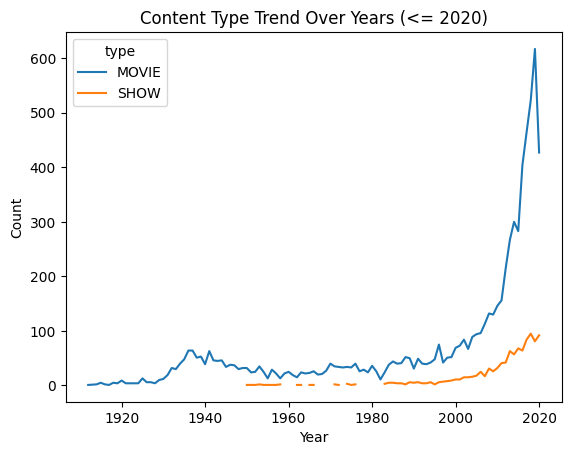

In [ ]:
# Chart - 19 visualization code

# Filter data for years <= 2020
filtered_df = df[df['release_year'] <= 2020]

# Group and plot
year_type = filtered_df.groupby(['release_year', 'type']).size().unstack()

year_type.plot()
plt.title("Content Type Trend Over Years (<= 2020)")
plt.xlabel("Year")
plt.ylabel("Count")
plt.show()

##### 1. Purpose

A line chart is ideal for comparing trends over time between multiple categories like movies and shows.

##### 2. insights

Both movies and shows have increased over time, but movies dominate throughout, while shows have grown more noticeably in recent years.

##### 3. Business impact

* Positive: Growth in shows indicates increasing focus on long-term engagement content.
* Negative: Movies still dominate heavily, which may limit user retention compared to series-based content.

#### Chart - 20: Top 10 Most Popular Content (Votes vs Score)

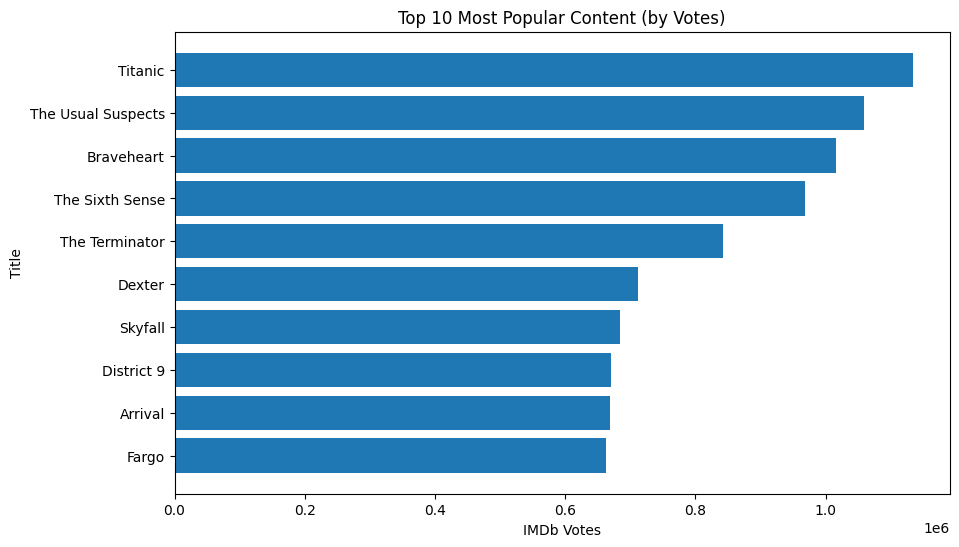

In [40]:
# Chart - 20 visualization code

# Get top 10 most voted content
top_popular = df.sort_values(by='imdb_votes', ascending=False).head(10)

plt.figure(figsize=(10,6))
plt.barh(top_popular['title'], top_popular['imdb_votes'])
plt.xlabel("IMDb Votes")
plt.ylabel("Title")
plt.title("Top 10 Most Popular Content (by Votes)")
plt.gca().invert_yaxis()
plt.show()

##### 1. Purpose

A horizontal bar chart is used to highlight the most popular content based on IMDb votes, making comparison easy and clear.

##### 2. insights

A small number of titles receive extremely high votes, showing that popularity is concentrated among a few top-performing contents.

##### 3. Business impact

* Positive: Helps identify blockbuster content that drives platform engagement.
* Negative: Heavy reliance on a few popular titles may reduce overall content balance.

## **5. Solution to Business Objective**

To achieve the business objective of improving user engagement and content performance, the client should focus on a data-driven content strategy.

* Prioritize high-performing genres like Drama and Comedy, as they attract more viewers.
* Increase investment in TV shows, as they tend to have better ratings and improve long-term user retention.
* Focus on quality over quantity, since most content has average ratings and only a few titles perform exceptionally well.
* Leverage popular actors and directors to boost audience engagement.
* Expand content production across diverse countries to reach a global audience.
* Avoid over-investing in long-duration content, as runtime has little impact on ratings.
* Promote high-vote content more effectively, as popularity slightly influences ratings.

Overall, a balanced approach combining content quality, diversity, and audience preference analysis will help maximize growth and platform success.

## **Key Insights**

- Movies dominate the platform, but TV shows have better rating consistency  
- Drama and Comedy are the most popular genres  
- Most content has average ratings (5–7 range)  
- IMDb votes slightly influence ratings  
- Runtime has little impact on content success  
- Content production is concentrated in a few countries  

# **Conclusion**

This analysis of the Amazon Prime dataset provided valuable insights into content trends, audience preferences, and factors influencing content performance. It was observed that movies dominate the platform, but TV shows tend to have slightly better ratings, making them important for long-term user engagement.

Genres like Drama and Comedy are the most popular, while most content falls within an average IMDb rating range of 5 to 7. The analysis also showed that factors like runtime and release year have minimal impact on ratings, whereas popularity (IMDb votes) has a slight positive influence.

Additionally, content production is concentrated in a few countries, highlighting opportunities for expanding global diversity. The study emphasizes that content success depends on a combination of factors rather than a single variable.

Overall, the project highlights the importance of a balanced content strategy focused on quality, diversity, and audience preferences to enhance platform growth and user satisfaction.